In [11]:
%pip install scikit-learn
%pip install pandas
%pip install openpyxl
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.5 MB 15.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 18.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 32.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 41.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- -----------------------------

In [8]:
import pandas as pd
import numpy as np
import openpyxl

df = pd.read_excel("Random Forest Data.xlsx", header=1, usecols="B:J")

stream = df[df["Rain or Stream"].str.lower().eq("stream")].copy()

feature_col = ["Site ID", "Temperature ", "Discharge (m3/s)"]

cut = int(len(stream) * 0.8)
train = stream.iloc[:cut]
test  = stream.iloc[cut:]

x_train = train[feature_col]
y_train = train["δ18O"]

x_test = test[feature_col]
y_test = test["δ18O"]

1.9.0
Regression slope: 0.324, intercept: -2.071


<Axes: title={'center': 'Random Forest Regression Results'}, xlabel='observed_d18O', ylabel='predicted_d18O'>

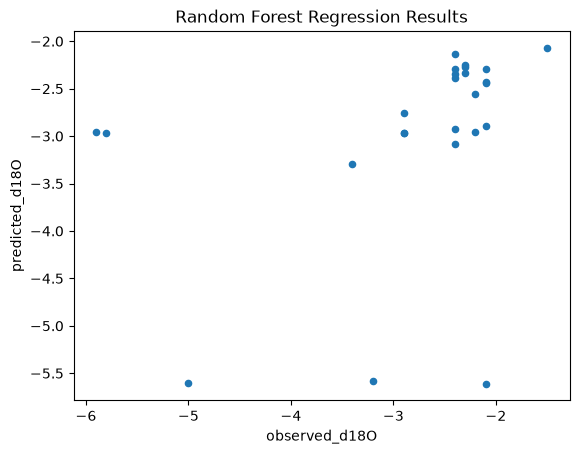

In [15]:
import sklearn
import sklearn.ensemble as ensemble
import matplotlib.pyplot as plt
print(sklearn.__version__)

regressor = ensemble.RandomForestRegressor()
regressor.fit(x_train, y_train)

y_pred = regressor.predict(x_test)

results = pd.DataFrame({
    "observed_d18O": y_test,
    "predicted_d18O": y_pred
})

regression = sklearn.linear_model.LinearRegression().fit(results[["observed_d18O"]], results["predicted_d18O"])
print(f"Regression slope: {regression.coef_[0]:.3f}, intercept: {regression.intercept_:.3f}")

results.plot.scatter(x="observed_d18O", y="predicted_d18O", title="Random Forest Regression Results")
